# Exercise 1.

In this section, I am reconstructing the Figure 2.2 of Sutton & Barto, with an added Optimal Values method and UCB method.

### 1.1 Violin Plot of the Reward Distribution


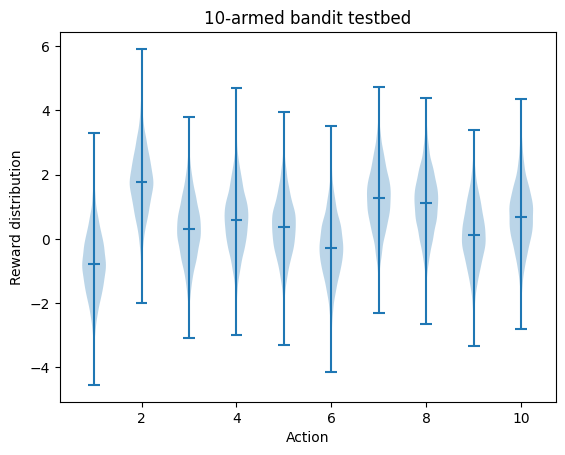

In [ ]:
from numpy.typing import NDArray
import numpy as np

def bandit_reward(q_star: NDArray[np.float64]) -> NDArray[np.float64]:
    return np.random.normal(loc=q_star, scale=1)

import matplotlib.pyplot as plt

def plot_bandit_testbed(n_samples: int, q_star: NDArray[np.float64]):

    k = len(q_star)

    # Generate n_samples per action 
    samples: NDArray[np.float64] = np.random.normal(
        loc=q_star[:, None],   # broadcast means
        scale=1,
        size=(k, n_samples)
    )   # [k x n_samples]

    plt.violinplot(samples.T, showmeans=True)

    plt.xlabel("Action")
    plt.ylabel("Reward distribution")
    plt.title("10-armed bandit testbed")

    plt.show()


q_star = np.random.randn(10)
plot_bandit_testbed(5000, q_star)


### 1.2 Average Reward and Optimal Policy (%)

In [ ]:
import numpy as np
from numpy.typing import NDArray

def k_armed_bandit_sim(epsilon: int,
                       Q_init: float = 0.0,
                       c: float  = 0.0,
                       runs: int = 2000,
                       steps: int = 1000,
                       k: int = 10
    ) -> tuple[NDArray[np.float64], NDArray[np.float64]]:

    q_star: NDArray[np.float64] = np.random.randn(runs, k) # True action values [2000 x 10]
    Q: NDArray[np.float64] = np.ones((runs, k))* Q_init    # Estimates [2000 x 10]
    N: NDArray[np.float64] = np.zeros((runs, k))           # Counts [2000x10] 

    # Collect average rewards and optimal action for each step
    avg_rewards: NDArray[np.float64] = np.zeros(steps) 
    optimal_action: NDArray[np.float64] = np.zeros(steps)
    for t in range(steps):

        actions: NDArray[np.int_] = np.zeros(runs, dtype=int)

        for run in range(runs):
            # UCB
            if c>0:
                ucb = np.zeros(k)
                for a in range(k):
                    if N[run, a] == 0:
                        ucb[a] = np.inf 
                    else:
                        ucb[a] = Q[run, a] + c * np.sqrt(np.log(t+1)/N[run, a])
                
                actions[run] = np.argmax(ucb)

            # epsilon-greedy
            else:
                if np.random.rand() < epsilon:
                    actions[run] = np.random.randint(k)
                else:
                    actions[run] = np.argmax(Q[run])

        rewards: NDArray[np.int_] = np.random.normal(loc=q_star[np.arange(runs), actions],
                                                     scale=1)

        # Update counts and estimates
        N[np.arange(runs), actions] += 1
        Q[np.arange(runs), actions] += ((rewards - Q[np.arange(runs), actions]) 
                                       / N[np.arange(runs), actions])

        avg_rewards[t] = np.mean(rewards)  
        optimal_action[t] = np.mean(actions == np.argmax(q_star, axis=1))

    return avg_rewards, optimal_action 



For now, I will present the UCB with an arbirary parameter (c=2) method along with others.

In [74]:
avg_r_greedy, opt_greedy = k_armed_bandit_sim(0.0)
avg_r_001, opt_001 = k_armed_bandit_sim(0.01)
avg_r_01, opt_01 = k_armed_bandit_sim(0.1)
avg_r_optimistic, opt_optiminstic = k_armed_bandit_sim(0.0, Q_init=5.0)
avg_r_ucb, opt_ucb = k_armed_bandit_sim(0.0, c=2.0)

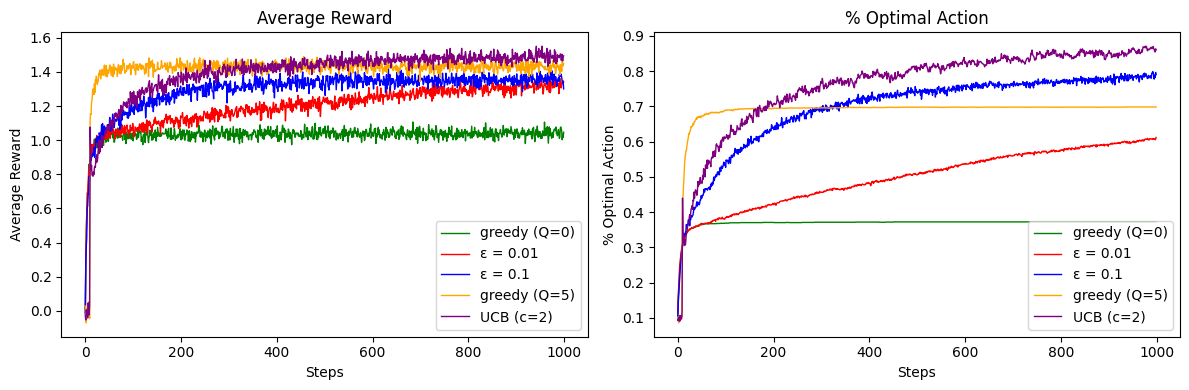

In [75]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(avg_r_greedy, label="greedy (Q=0)", linewidth=1, color="green")
ax[0].plot(avg_r_001, label="ε = 0.01", linewidth=1, color="red")
ax[0].plot(avg_r_01, label="ε = 0.1", linewidth=1, color="blue")
ax[0].plot(avg_r_optimistic, label="greedy (Q=5)", linewidth=1, color="orange")
ax[0].plot(avg_r_ucb, label="UCB (c=2)", linewidth=1, color="purple")

ax[0].set_title("Average Reward")
ax[0].set_xlabel("Steps")
ax[0].set_ylabel("Average Reward")
ax[0].legend()

ax[1].plot(opt_greedy, label="greedy (Q=0)", linewidth=1, color="green")
ax[1].plot(opt_001, label="ε = 0.01", linewidth=1, color="red")
ax[1].plot(opt_01, label="ε = 0.1", linewidth=1, color="blue")
ax[1].plot(opt_optiminstic, label="greedy (Q=5)", linewidth=1, color="orange")
ax[1].plot(opt_ucb, label="UCB (c=2)", linewidth=1, color="purple")

ax[1].set_title("% Optimal Action")
ax[1].set_xlabel("Steps")
ax[1].set_ylabel("% Optimal Action")
ax[1].legend()

plt.tight_layout()
plt.show()

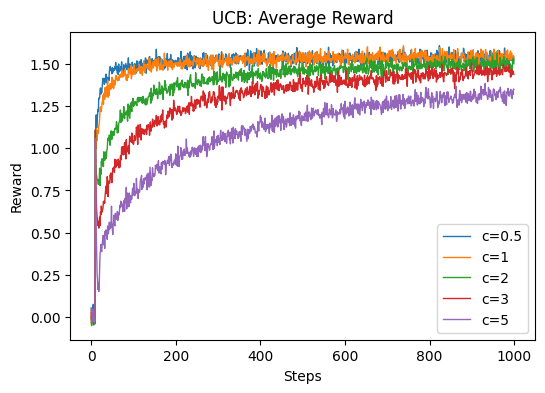

In [ ]:
import matplotlib.pyplot as plt
c_values = [0.5, 1, 2, 3, 5]

ucb = {}
avg_scores = []

for c in c_values:
    avg_r, opt = k_armed_bandit_sim(epsilon=0.0, c=c)
    ucb[c] = (avg_r, opt)
    avg_scores.append(np.mean(avg_r))

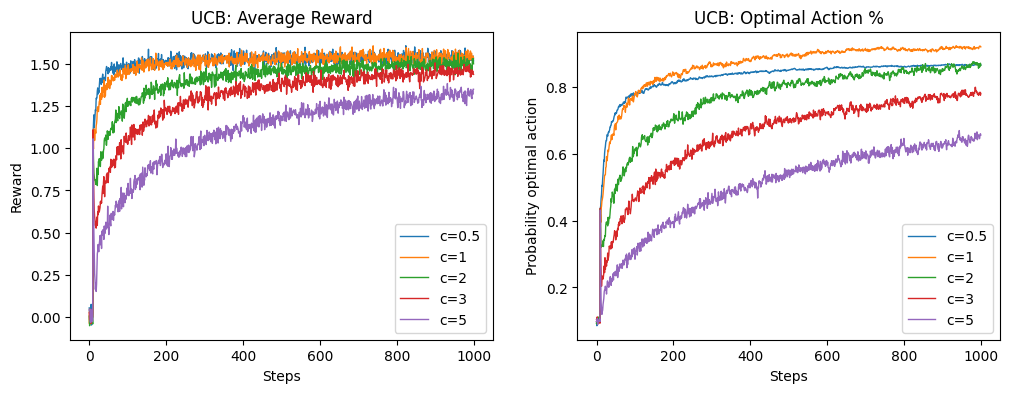

In [80]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

for c in c_values:
    avg_r, _ = ucb[c]
    ax[0].plot(avg_r, label=f"c={c}", linewidth=1)

ax[0].set_title("UCB: Average Reward")
ax[0].set_xlabel("Steps")
ax[0].set_ylabel("Reward")
ax[0].legend()

for c in c_values:
    _, opt = ucb[c]
    ax[1].plot(opt, label=f"c={c}", linewidth=1)

ax[1].set_title("UCB: Optimal Action %")
ax[1].set_xlabel("Steps")
ax[1].set_ylabel("Probability optimal action")
ax[1].legend()
plt.show()

We observe that c=0.5 and c=1 consistently yeilds the highest mean reward and the largest fraction of optimal action selections. We also expect c = 0.5 to have higher aveage reward (across time steps) than c = 1, but c = 1 have consistently higher fraction of optimal actions chosen. Considering these factors I choose c = 1, as the best exploration parameter value for UCB.

In [81]:
avg_r_ucb_optimal, opt_ucb_optimal = k_armed_bandit_sim(0.0, c=1.0)

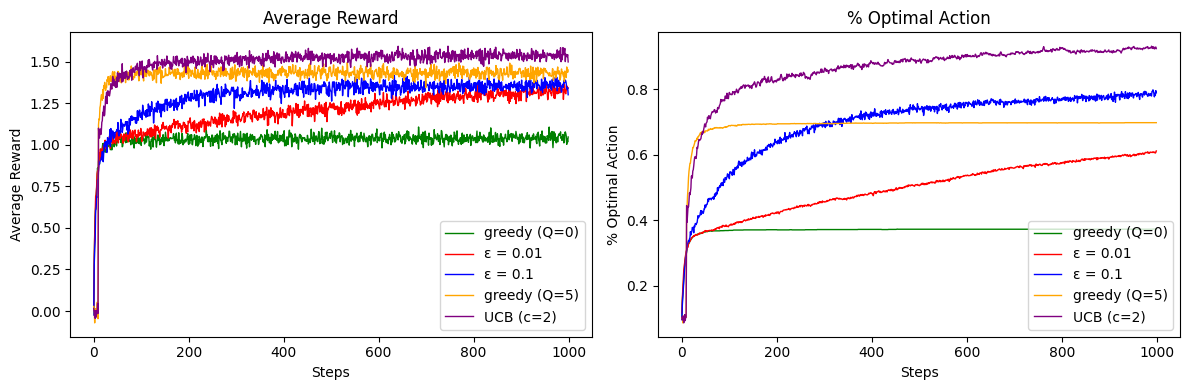

In [82]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(avg_r_greedy, label="greedy (Q=0)", linewidth=1, color="green")
ax[0].plot(avg_r_001, label="ε = 0.01", linewidth=1, color="red")
ax[0].plot(avg_r_01, label="ε = 0.1", linewidth=1, color="blue")
ax[0].plot(avg_r_optimistic, label="greedy (Q=5)", linewidth=1, color="orange")
ax[0].plot(avg_r_ucb_optimal, label="UCB (c=2)", linewidth=1, color="purple")

ax[0].set_title("Average Reward")
ax[0].set_xlabel("Steps")
ax[0].set_ylabel("Average Reward")
ax[0].legend()

ax[1].plot(opt_greedy, label="greedy (Q=0)", linewidth=1, color="green")
ax[1].plot(opt_001, label="ε = 0.01", linewidth=1, color="red")
ax[1].plot(opt_01, label="ε = 0.1", linewidth=1, color="blue")
ax[1].plot(opt_optiminstic, label="greedy (Q=5)", linewidth=1, color="orange")
ax[1].plot(opt_ucb_optimal, label="UCB (c=2)", linewidth=1, color="purple")

ax[1].set_title("% Optimal Action")
ax[1].set_xlabel("Steps")
ax[1].set_ylabel("% Optimal Action")
ax[1].legend()

plt.tight_layout()
plt.show()

In the following I am comparing the mean rewards over time on a log scale. We indeed find that c = 0.5 yields the highest average reward over time

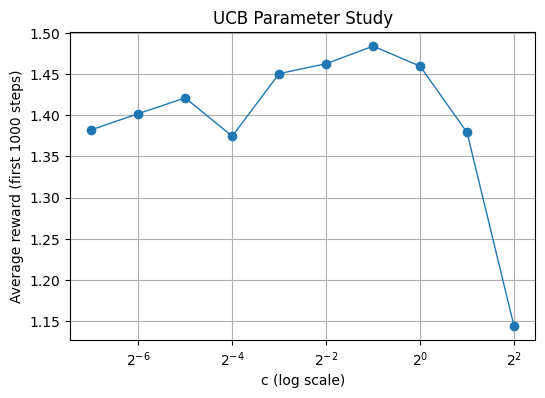

In [83]:
c_values = [1/128, 1/64, 1/32, 1/16, 1/8, 1/4, 1/2, 1, 2, 4]
avg_scores = []

for c in c_values:
    avg_r, _ = k_armed_bandit_sim(epsilon=0.0, c=c)
    
    # average over time (area under curve)
    score = np.mean(avg_r)
    
    avg_scores.append(score)

import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.plot(c_values, avg_scores, marker='o', linewidth=1)

plt.xscale('log', base=2)  

plt.xlabel("c (log scale)")
plt.ylabel("Average reward (first 1000 steps)")
plt.title("UCB Parameter Study")

plt.grid(True)
plt.show()